# **Topic Modeling**

In [2]:
# ============================================================
# Setup
# ============================================================
!pip install langdetect
!pip install bertopic
!pip install pymorphy3
!pip install stanza
import pandas as pd
import re
import umap
import numpy as np
from sentence_transformers import SentenceTransformer, models
import umap.umap_ as umap
import hdbscan
from langdetect import detect
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import pymorphy3
import stanza
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer


  Using cached langdetect-1.0.9.tar.gz (981 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=5a08da938a41e70dee9374d1554a41b2708fed05984801d2fd507a635228aa4e
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 30.7 MB/s eta 0:00:00


/tmp/ipykernel_4392/4160292792.py:12: DeprecationWarning: Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.
  from sentence_transformers import SentenceTransformer, models


## **Project Workflow**
topic_modeling_workflow.svg

## **1. Data Preparation**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving full_df.xlsx to full_df.xlsx


In [4]:
full_df = pd.read_excel('full_df.xlsx')

In [5]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468 entries, 0 to 6467
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   University Name          6468 non-null   object 
 1   Review Text              6467 non-null   object 
 2   Timestamp                6468 non-null   object 
 3   Year                     6468 non-null   int64  
 4   Manual_Category          1866 non-null   object 
 5   Reviews Count            6275 non-null   float64
 6   Average Rating           6275 non-null   float64
 7   Review Date              6351 non-null   object 
 8   Review Rating            6275 non-null   float64
 9   bert_sentiment           6275 non-null   float64
 10  Sentiment_Category_BERT  6468 non-null   object 
 11  Star_Sentiment_Category  6468 non-null   object 
 12  Match                    6275 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 657.0+ KB


In [6]:
full_df["Match"] = full_df["Star_Sentiment_Category"] == full_df["Sentiment_Category_BERT"] # select only negative reviews for clustering

In [7]:
filtered_df = full_df[
    (full_df["Sentiment_Category_BERT"] == "negative") &
    (full_df["Match"] == True) | (full_df["Manual_Category"] == "negative")
]

negative_reviews_df = filtered_df[["Review Text"]].reset_index(drop=True)

negative_reviews_df.head()

,Review Text
0,"Не успела даже поступить, просто позвонила зад..."
1,Вчуся на факультеті управління фінансами і біз...
2,я закончил наш харьковский радиотехникум и хот...
3,Я обурена. Навіщо так багато платити за навчан...
4,"А ти сиди ночами, зір втрачай, поставу, здоров..."


In [8]:
# Create a new column containing the cleaned review text
def preprocess_text_for_embeddings(text):
    """
    Minimal preprocessing before generating Sentence Embeddings.
    - Fix glued words after punctuation, e.g., "хорошо.Кто" -> "хорошо. Кто"
    - Removes extra spaces.
    - Ensures text is a clean string suitable for embedding models.
    """
    if not isinstance(text, str):
        return ""

    # Fix glued words after punctuation, e.g., "хорошо.Кто" -> "хорошо. Кто"
    clean_text = re.sub(
        r'([^\w\s])([^\s])',
        r'\1 \2',
        text
    )
    # Remove extra spaces
    cleaned_text = re.sub(r"\s+", " ", clean_text).strip()

    return cleaned_text

In [9]:
negative_reviews_df["Cleaned_Text"] = negative_reviews_df["Review Text"].apply(preprocess_text_for_embeddings)

In [10]:
# embeddings
# ==========================================
# 1. Build SentenceTransformer
# ==========================================

word_embedding_model = models.Transformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    max_seq_length=512
)

pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode="mean"
)

model = SentenceTransformer(
    modules=[word_embedding_model, pooling_model]
)

# ==========================================
# 2. Generate embeddings
# ==========================================

texts = negative_reviews_df["Cleaned_Text"].fillna("").tolist()

embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(embeddings.shape)


config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Batches:   0%|          | 0/78 [00:00<?, ?it/s]

(2491, 768)


## **2. Topic Modeling**

## 2.1 UMAP + HDBSCAN

HDBSCAN is used to identify dense semantic regions in the embedding space. Unlike KMeans, it does not require predefining the number of clusters and can label ambiguous points as noise (-1).

In [11]:
# ==========================================
# 3. UMAP reduction
# ==========================================

umap_model = umap.UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

embeddings_umap = umap_model.fit_transform(embeddings)

print(embeddings_umap.shape)

(2491, 5)


In [12]:
# ==========================================
# 4. HDBSCAN clustering
# ==========================================

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=3,
    metric="euclidean",
    prediction_data=True
)

cluster_labels = clusterer.fit_predict(embeddings_umap)

negative_reviews_df["Cluster"] = cluster_labels
negative_reviews_df["Probability"] = clusterer.probabilities_

In [13]:
negative_reviews_df["Cluster"].value_counts().sort_index()

,count
Cluster,
-1,938
0,53
1,54
2,57
3,92
4,256
5,198
6,80
7,52


In [14]:
for cluster in sorted(negative_reviews_df["Cluster"].unique()):

    if cluster == -1:
        continue

    print("=" * 80)
    print(f"CLUSTER {cluster}")

    representative_reviews = (
        negative_reviews_df[
            negative_reviews_df["Cluster"] == cluster
        ]
        .sort_values("Probability", ascending=False)
        .head(10)
    )

    for review in representative_reviews["Cleaned_Text"]:
        print("-", review)

CLUSTER 0
- Це не про університет але напряму з ним зв' язано. Будь ласка шановна адміністрація університету якщо хтось з вас це читає візьміть будь ласка до уваги! Зробіть нарешті щось з гуртожитком № 3! !! ! Відношення до студентів з боку завідуючої просто жахливе! !! Вона з легкістю дозволяє собі ображати студентів, піднімати голос просто так без причини. При найменшому обурені відразу ж погрожує виселити, а на наступний рік просто не дозволить поселитися. Звісно дисципліна повинна бути але страждають навіть ті хто її ні разу не порушував. Через цей факт ваш університет навіть не хочеться рекомендувати друзям. Тому зробіть якісь висновки.
- пожалейте своих детей. не отдавайте их на юрфак, не совершайте чужих ошибок. Никаких знаний, коррупция, хамство. Через 2 года завбрали документы и перевелись. Очень жалею, что повелась на мнимые рейтинги и отдала сюда ребенка.
- УЖАСНО ТО, ЧТО ПРЕПОДАВАТЕЛИ СОВСЕМ ОБЛЕНИЛИСЬ ЧИТАТЬ ТЕМЫ САМИ, ПОЗОР СТОЯТЬ И ЧИТАТЬ С ТЕЛЕФОНА, а потом как не в чем

### Interpretation

The UMAP + HDBSCAN approach identified four distinct thematic clusters. Based on the representative reviews, the clusters were interpreted as:

- **Cluster 5** – Corruption
- **Cluster 10** – Attitudes Toward Students
- **Cluster 9** – Campus Сonditions
- **Cluster 11** – Education Quality

## 2.2 UMAP + K-Means

KMeans is applied on UMAP-reduced embeddings to partition the dataset into a fixed number of clusters.
This approach ensures full assignment of all samples, unlike density-based methods.

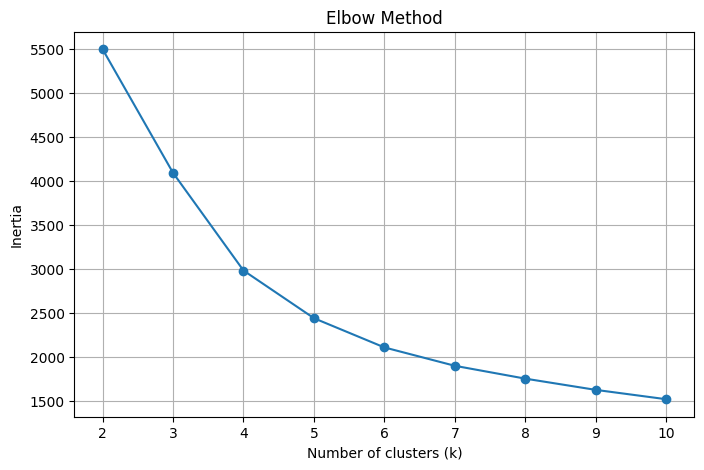

In [15]:
# Determine the optimal number of clusters using the Elbow Method
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(embeddings_umap)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

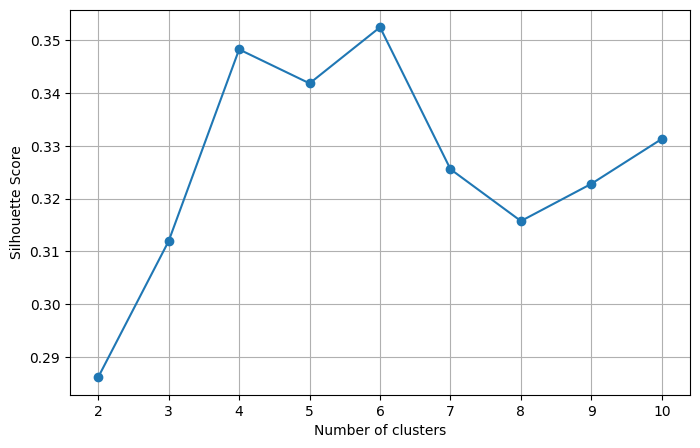

In [16]:
# Determine the optimal number of clusters using thesilhouette_score
scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(embeddings_umap)

    score = silhouette_score(
        embeddings_umap,
        labels
    )

    scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

Cluster Interpretation
To better understand the semantic meaning of each cluster, the reviews closest to each cluster centroid are displayed. These reviews serve as representative examples of the corresponding cluster.

In [17]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)
# Retrieve the most representative reviews for each cluster
negative_reviews_df["Cluster"] = kmeans.fit_predict(embeddings_umap)
distances = kmeans.transform(embeddings_umap)
for cluster in range(kmeans.n_clusters):
  print("=" * 80)
  print(f"CLUSTER {cluster}")
  closest = np.argsort(distances[:, cluster])[:10]
  for review in negative_reviews_df.iloc[closest]["Cleaned_Text"]:
    print("-", review)

CLUSTER 0
- Хаи - это угрозы отчисления, не подписания документов из- за не явки на репетицию. Говорить, что сдача курсового проекта не важна, ведь главное поставить рекорд! !! ! Ведь это реклама вуза. Окей, а отчисления за то, что у тебя индивидуальный график? Это разве не реклама? Преподаватели. Большая часть считают себя единственным здравым человеком. Проверять программу по скринам? Почему бы и нет. Держать студентов до 7 вечера, не давая дополнительных баллов. Оскорблять студентов на лекциях, конечно же. На лекциях вместо какого- то материала рассказывать " весёлые истории" . Так же куча лаб, которые физически не успеваешь выполнить. Отдельно хотелось бы сказать про общежития, в основном речь пойдёт о китайке. 11- куча клопов, тараканов, жить не возможно. 12- ужасный комендант, которая возомнила себя царицей. Отказы в подписании заявлений, оскорбления, навешивания хозок. Также куча тараканов, клопов чуть меньше. Может когда- то это был хороший вуз, но сейчас это просто рекламирующ

### Interpretation

The UMAP + K-Means approach identified four thematic clusters. Based on the representative reviews, the clusters were interpreted as:

- **Cluster 1** – Corruption
- **Clusters 2 and 4** – Education Quality
- **Cluster 3** – Campus Conditions

## 2.3 BERTopic

Prepare stop words and a lemmatization function to improve c-TF-IDF topic representations

In [ ]:
stopwords_ua = [
    "а", "але", "в", "і", "й", "та", "як", "що", "це", "ця", "цей", "цею",
    "тільки", "чи", "чиє", "чия", "хто", "коли", "де", "так", "тут",
    "там", "мій", "твій", "ваш", "наш", "його", "її", "їх", "ви", "ми", "вони",
    "з", "до", "по", "на", "із", "без", "під", "над", "від", "для",
    "якщо", "свої", "я", "який", "тих", "вона", "вони", "їхній", "такий",
    "тоді", "цеї", "ті", "та", "бо", "ось", "ще", "надто", "уже", "б", "моя", "свій",
    "своє", "йому", "нам", "їм", "мені", "просто", "про", "вас", "те",
    "при", "щоб", "тому", "них", "цього", "нас", "вже", "або", "цьому", "нау", "ти", "тебе",
    "мене", "чого", "то", "було", "були", "буде", "була", "яка", "які", "такий", "всі", "є",
    "бути", "навіть", "той", "кожен", "кожний", "перед", "якби", "будь-який", "ех",
    "то", "весь", "щось", "якийсь", "зато", "хоч", "би", "по"
]
stopwords_ru = [
    "и", "в", "во", "что", "он", "на", "я", "с", "со", "как", "а", "то",
    "все", "она", "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за",
    "бы", "по", "только", "ее", "мне", "было", "вот", "от", "меня", "еще", "о",
    "из", "ему", "теперь", "когда", "даже", "ну", "вдруг", "ли", "если", "уже",
    "или", "нибудь", "опять", "уж", "вам", "ведь", "там", "потом", "себя", "ничего",
    "ей", "может", "они", "тут", "мочь", "мена", "где", "есть", "надо", "ней", "для", "мы",
    "тебя", "их", "чем", "была", "сам", "чтоб", "без", "будто", "чего", "раз",
    "тоже", "себе", "под", "будет", "ж", "мой", "твой", "моя", "нам", "им", "это",
    "вас", "того", "те", "при", "этом", "кто", "нау", "чтобы", "этого", "свой", "быть", "такой",
    "тот", "каждый", "хотя", "если", "бы", "всё", "этот", "ещё", "который", "то", "что-то",
    "какой-то", "где-то", "как-то", "как бы", "ну", "вот", "весь", "здесь"
]
all_stopwords = set(stopwords_ru + stopwords_ua)

In [18]:
# Lemmatization
# Initialize pymorphy3 morphological analyzer for Russian language
morph_ru = pymorphy3.MorphAnalyzer(lang='ru')
# Initialize Stanza pipeline for Ukrainian language
nlp_uk = stanza.Pipeline('uk', processors='tokenize,mwt,pos,lemma')

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.13.0/resources/resources.json


models/tokenize/iu.pt:   0%|          | 0.00/646k [00:00<?, ?B/s]

models/mwt/iu.pt:   0%|          | 0.00/556k [00:00<?, ?B/s]

models/pos/iu_charlm.pt:   0%|          | 0.00/36.1M [00:00<?, ?B/s]

models/lemma/iu_nocharlm.pt:   0%|          | 0.00/4.30M [00:00<?, ?B/s]

models/backward_charlm/conll17.pt:   0%|          | 0.00/20.8M [00:00<?, ?B/s]

models/forward_charlm/conll17.pt:   0%|          | 0.00/20.8M [00:00<?, ?B/s]

models/pretrain/conll17.pt:   0%|          | 0.00/109M [00:00<?, ?B/s]

INFO:stanza:Loading these models for language: uk (Ukrainian):
| Processor | Package     |
---------------------------
| tokenize  | iu          |
| mwt       | iu          |
| pos       | iu_charlm   |
| lemma     | iu_nocharlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Done loading processors!


In [ ]:
def lemmatize_text(text):
    # Detect the language of the text
    lang = detect(text)
    print(f"Detected language: {lang}")

    # Українська та російська стоп-слова повинні бути в нижньому регістрі
    global all_stopwords

    # Lemmatization for Russian text
    if lang == 'ru':
        tokens = text.lower().split()
        lemmatized_tokens = [morph_ru.parse(word)[0].normal_form for word in tokens if word.isalpha()]

    # Lemmatization for Ukrainian text
    elif lang == 'uk':
        doc = nlp_uk(text.lower())
        lemmatized_tokens = [word.lemma for sent in doc.sentences for word in sent.words if word.text.isalpha()]

    else:
        lemmatized_tokens = text.lower().split()

    # Видаляємо стоп-слова
    lemmatized_tokens = [t for t in lemmatized_tokens if t not in all_stopwords]

    # Повертаємо як рядок для CountVectorizer
    return " ".join(lemmatized_tokens)


In [ ]:
# ==========================================
# 1️⃣ Define custom CountVectorizer
# ==========================================
# Uses a custom text preprocessing function (lemmatization)
vectorizer_model = CountVectorizer(
    preprocessor=lemmatize_text,
    stop_words=None
)

# ==========================================
# 2️⃣ Define embedding model
# ==========================================
# SentenceTransformer converts each review into a dense vector representation.
# This multilingual model captures semantic similarity across languages.
embedder = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

# ==========================================
# 3️⃣ Define custom HDBSCAN clustering model
# ==========================================
# HDBSCAN finds dense clusters in the embedding space.
# The parameters control the minimum cluster size and distance metric.
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=10,
    metric='euclidean',
    cluster_selection_method='eom'
)

# ==========================================
# 4️⃣ Initialize BERTopic model
# ==========================================
# Combines the embedding model, vectorizer, and clustering algorithm
# to automatically detect coherent topics in the review corpus.
topic_model = BERTopic(
    embedding_model=embedder,
    vectorizer_model=vectorizer_model,
    hdbscan_model=hdbscan_model
)

# ==========================================
# 5️⃣ Fit BERTopic model on review text
# ==========================================
# Apply the model to the cleaned reviews to generate topic assignments
# and probabilities of each document belonging to a given topic.
reviews = negative_reviews_df['Cleaned_Text'].tolist()
topics, probs = topic_model.fit_transform(reviews)

# ==========================================
# 6️⃣ Display topic summary information
# ==========================================
# Shows topic IDs, their frequency, and representative keywords.
topic_info = topic_model.get_topic_info()
print(topic_info.head(10))  # top-10 topics by size

# ==========================================
# 7️⃣ Create a DataFrame linking reviews to topics
# ==========================================
# Adds topic labels and keywords to each review for interpretation.
df_topics = pd.DataFrame({"review": reviews, "topic": topics})
df_topics = df_topics.merge(topic_info[['Topic', 'Name']], left_on='topic', right_on='Topic', how='left')
df_topics = df_topics[['review', 'topic', 'Name']]
df_topics.rename(columns={'Name': 'topic_keywords'}, inplace=True)

print(df_topics.head(10))  # first 10 reviews with topic assignments


Detected language: ru
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: uk
Detected language: uk
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: uk
Detected language: ru
Detected language: ru
Detected language: ru
Detected l

### Interpretation

BERTopic identified several fine-grained topics. The dominant themes include:

- **Corruption**
- **Education Quality** (represented by multiple subtopics)
- **Campus and Dormitory Conditions**
- **Attitudes Toward Students**
- **Admission Process**
- **Philology and Foreign Language Studies**

Compared with the previous approaches, BERTopic provides a more detailed topic structure while preserving the main themes identified by both UMAP + HDBSCAN and UMAP + K-Means.

## **3. Results Comparison**

| Theme                       | UMAP + HDBSCAN | UMAP + K-Means | BERTopic |
| --------------------------- | :------------: | :------------: | :------: |
| Corruption                  |        ✅       |        ✅       |     ✅    |
| Education Quality           |        ✅       |        ✅       |     ✅    |
| Campus Conditions           |        ✅       |        ✅       |     ✅    |
| Attitudes Toward Students   |        ✅       |        —       |     ✅    |
| Academic Process Management |        —       |        —       |     ✅    |


The comparison of the three approaches demonstrates that Corruption, Education Quality, and Campus Conditions were consistently identified across all methods, indicating that these are stable themes within the dataset. Attitudes Toward Students emerged in both density-based clustering and BERTopic, while Academic Process Management was identified only by BERTopic. This suggests that BERTopic provides a more fine-grained representation of the corpus by separating administrative and academic process-related discussions into a distinct topic.

## **4. Conclusions**

Based on the comparative analysis, five key themes were selected for further analysis: **Corruption**, **Education Quality**, **Campus Conditions**, **Attitudes Toward Students**, and **Academic Process Management**.

These themes will be used to manually annotate a subset of negative reviews, creating a labeled dataset for supervised text classification. The resulting model will enable automatic categorization of new reviews, helping identify recurring issues, monitor their prevalence over time, and support timely decision-making.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!jupyter nbconvert --to notebook --ClearMetadataPreprocessor.enabled=True \
    --output "/content/drive/MyDrive/training_model_.ipynb" \
    "/content/drive/MyDrive/training_model.ipynb"